# Обучение модели

В данном ноутбуке я обучаю модель на датесете, который получил из ``1_moral_legitimicy.ipynb``

In [ ]:
import pandas as pd # для работой с таблицами
import numpy as np # для математических вычислений 
from sklearn.model_selection import train_test_split # для разбивки на тестовую и обучающую выборку
from datasets import Dataset # для создания датасетов для модели 
from transformers import (
    AutoTokenizer, # для токенезации 
    AutoModelForSequenceClassification, # для пайплайна обучения 
    TrainingArguments, # для агрументов обучения 
    Trainer, # для обучения 
    DataCollatorWithPadding # для формирования правильных бачей 
)
from sklearn.metrics import accuracy_score, f1_score # для метрик 
import matplotlib.pyplot as plt # для графиков
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # для confusion_matrix

Считываю датасет из ``1_moral_legitimicy.ipynb``

In [2]:
df = pd.read_csv("moral_legitimicy_annotated.csv")
df = df[["sentence", "moral_label"]].rename(columns={"moral_label": "label"})
df

,sentence,label
0,demand factors are affected by the increasing ...,0
1,the launch of entire online programs from some...,0
2,the fact that the courses offered by the best ...,0
3,"similarly, the fact that new generations are u...",0
4,"as an example, today it is possible to produce...",0
...,...,...
1665,this 200 billion yen will be used to support v...,0
1666,we know that achieving this goal will not be e...,0
1667,thank you for your continued support and dedic...,0
1668,the student supporters club scholarship contac...,0


Смотрю на баланс классов

<Axes: title={'center': 'Распределние классов (1 - моральная легитимация, 0 - нет )'}, ylabel='count'>

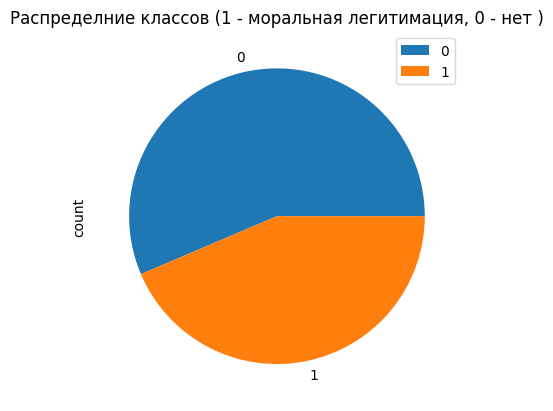

In [15]:
df['label'].value_counts().plot(kind='pie', legend=True, title='Распределние классов (1 - моральная легитимация, 0 - нет )')

Баланс класов соблюден

формирую тестовую и обучающие выборки

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

Загружаю токенизатор и токенизирую тексты

In [5]:
checkpoint = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize(example):
    return tokenizer(example["sentence"], truncation=True)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/1336 [00:00<?, ? examples/s]

Map:   0%|          | 0/334 [00:00<?, ? examples/s]

Загружаю модель и формирую батчи для дообучения

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Подбираю гиперпараметры и обучаю модель

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

training_args = TrainingArguments(
    output_dir="./moral_bert_output",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\kiril\AppData\Local\Temp\ipykernel_17644\3455356133.py:25: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: grigorii-kiriukhov (grigorii-kiriukhov-higher-school-of-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.509400,0.824071,0.814371,0.802548
2,0.440200,0.452522,0.844311,0.828947
3,0.225800,0.776191,0.844311,0.828947
4,0.118400,0.860232,0.844311,0.828947


TrainOutput(global_step=668, training_loss=0.3234617524518224, metrics={'train_runtime': 50.7333, 'train_samples_per_second': 105.335, 'train_steps_per_second': 13.167, 'total_flos': 361703701135680.0, 'train_loss': 0.3234617524518224, 'epoch': 4.0})

Формирую confusion matrix и датасет с неправильно размеченными классами.

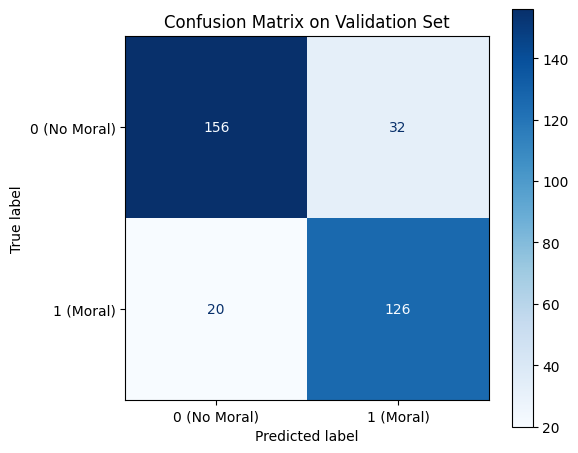

Некорректные предсказания (первые 5):


,sentence,true_label,predicted_label
0,it is also hoped that the project will broadly...,1,0
1,"uct staff asked pointed, important questions a...",0,1
2,this “utokyo way” was created to share what we...,0,1
3,#unleash professor mamokgethi phakeng vice-cha...,0,1
4,"research excellence rigorous, respected resear...",1,0


In [ ]:
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 (No Moral)", "1 (Moral)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix on Validation Set")
plt.tight_layout()
plt.show()

sentences = [test_dataset[i]["sentence"] for i in range(len(test_dataset))]
errors = pd.DataFrame({
    "sentence": sentences,
    "true_label": true_labels,
    "predicted_label": pred_labels
})
errors = errors[errors["true_label"] != errors["predicted_label"]].reset_index(drop=True)

errors.to_csv("moral_legitimacy_misclassified.csv", index=False)

print("Некорректные предсказания (первые 5):")
errors.head()